=== 実行パラメータ ===
SEED = 42
N = 100
BASE_GRAPH_TYPE = ER
P_ER = None
M_BA = 2
REGULAR_DEGREE = 4
ENTROPY_LOG_BASE = 2
OPERATION_MODE = hub
HUB_TARGET_EDGES = 40
STARIFY_NUM_LEAVES = 60
REMOVE_EDGE_FRAC = 0.3
ISOLATE_NUM_NODES = 10
SPLIT_RATIO = 0.5
TO_REGULAR_DEGREE = 4
使用した ER の p = 0.040404

=== Before_ER ===
ノード数                 : 100
エッジ数                 : 177
平均次数                 : 3.5400
密度                     : 0.035758
平均クラスタ係数         : 0.018500
連結成分数               : 4
平均最短距離(最大連結成分): 3.550687
最大連結成分比率         : 0.970000
次数エントロピー         : 2.921961 bits
正規化 次数エントロピー  : 0.879598
構造エントロピー         : 6.414887 bits
正規化 構造エントロピー  : 0.965537
von Neumann entropy      : 6.213814 bits
正規化 von Neumann entr. : 0.935272

=== After_hub ===
ノード数                 : 100
エッジ数                 : 217
平均次数                 : 4.3400
密度                     : 0.043838
平均クラスタ係数         : 0.106102
連結成分数               : 2
平均最短距離(最大連結成分): 2.856524
最大連結成分比率         : 0.990000
次数エントロピー         : 2.995223 bits
正

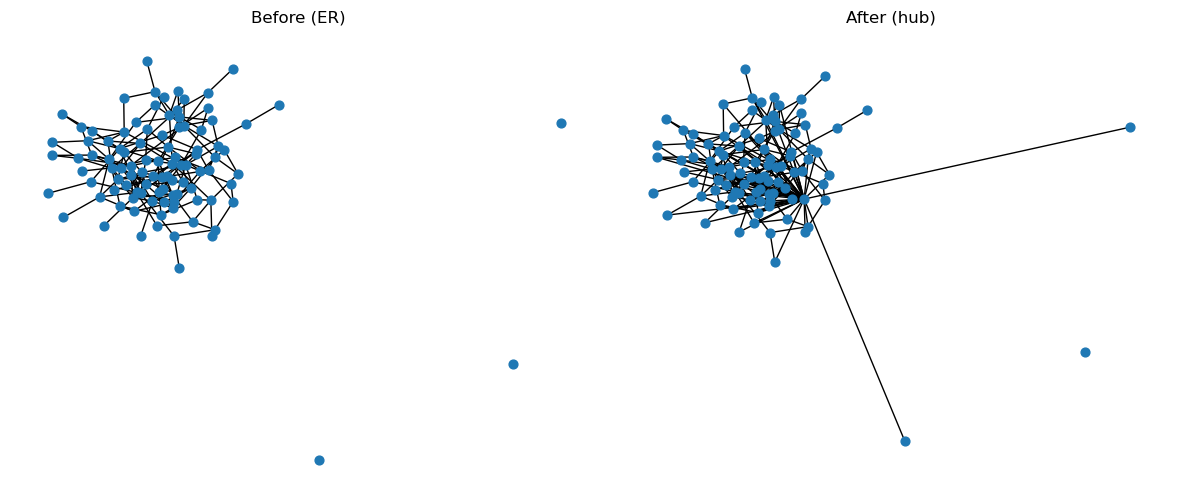

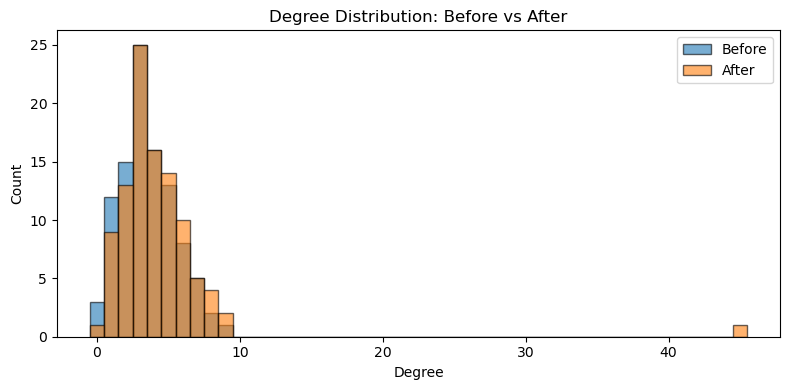

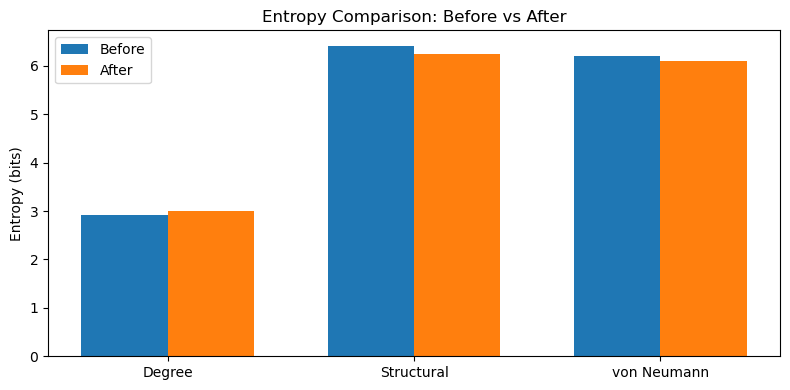

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import random


# =========================================
# 0. パラメータ（ここだけ触ればよい）
# =========================================

SEED = 42

# ノード数
N = 100

# 基準グラフ
# "ER", "BA", "REGULAR", "PATH", "STAR"
BASE_GRAPH_TYPE = "ER"

# ER 用
# None のとき BA の平均次数 2*M_BA にだいたい合わせる
P_ER = None

# BA 用
M_BA = 2

# REGULAR 用
REGULAR_DEGREE = 4

# エントロピーの対数底
# 2 -> bits, np.e -> nat
ENTROPY_LOG_BASE = 2

# 操作モード
# "none"
# "hub"
# "starify"
# "remove_edges_random"
# "isolate_nodes"
# "split_components"
# "to_path"
# "to_star"
# "to_regular"
OPERATION_MODE = "hub"

# -------------------------
# 各操作の強さ
# -------------------------

# hub: ノード 0 に何本追加接続するか
HUB_TARGET_EDGES = 40

# starify: ノード 0 を中心に何ノードをスター的に結ぶか
STARIFY_NUM_LEAVES = 60

# remove_edges_random: 全辺のうち何割削除するか
REMOVE_EDGE_FRAC = 0.30

# isolate_nodes: 先頭から何ノード孤立化するか
ISOLATE_NUM_NODES = 10

# split_components: 2グループ間の辺を削除して分断しやすくする
SPLIT_RATIO = 0.5   # 前半:後半 = 50:50

# to_regular 用
TO_REGULAR_DEGREE = 4

# 可視化
NODE_SIZE = 40
FIGSIZE_GRAPH_COMPARE = (12, 5)
FIGSIZE_HIST = (8, 4)
FIGSIZE_BAR = (8, 4)

# 比較表示
SHOW_GRAPH_PLOT = True
SHOW_DEGREE_HIST = True
SHOW_ENTROPY_BAR = True


# =========================================
# 1. 基本ユーティリティ
# =========================================
def get_log_fn(base):
    if base == 2:
        return np.log2
    elif base == np.e:
        return np.log
    else:
        return lambda x: np.log(x) / np.log(base)


def entropy_unit_name(base):
    if base == 2:
        return "bits"
    elif base == np.e:
        return "nat"
    else:
        return f"log base {base}"


def calc_default_p_er(n, m_ba):
    return (2 * m_ba) / (n - 1)


# =========================================
# 2. グラフ生成
# =========================================
def generate_base_graph():
    if BASE_GRAPH_TYPE == "ER":
        p_used = calc_default_p_er(N, M_BA) if P_ER is None else P_ER
        G = nx.erdos_renyi_graph(n=N, p=p_used, seed=SEED)
        meta = {"graph_type": "ER", "p_er": p_used}

    elif BASE_GRAPH_TYPE == "BA":
        G = nx.barabasi_albert_graph(n=N, m=M_BA, seed=SEED)
        meta = {"graph_type": "BA", "p_er": None}

    elif BASE_GRAPH_TYPE == "REGULAR":
        if (N * REGULAR_DEGREE) % 2 != 0:
            raise ValueError("REGULAR グラフでは N * REGULAR_DEGREE が偶数である必要があります。")
        G = nx.random_regular_graph(d=REGULAR_DEGREE, n=N, seed=SEED)
        meta = {"graph_type": "REGULAR", "p_er": None}

    elif BASE_GRAPH_TYPE == "PATH":
        G = nx.path_graph(N)
        meta = {"graph_type": "PATH", "p_er": None}

    elif BASE_GRAPH_TYPE == "STAR":
        G = nx.star_graph(N - 1)
        meta = {"graph_type": "STAR", "p_er": None}

    else:
        raise ValueError("BASE_GRAPH_TYPE は 'ER', 'BA', 'REGULAR', 'PATH', 'STAR' のいずれかにしてください。")

    return G, meta


# =========================================
# 3. エントロピー
# =========================================
def degree_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    degrees = [d for _, d in G.degree()]
    count = Counter(degrees)
    n_nodes = sum(count.values())

    if n_nodes == 0:
        return 0.0, 0.0, degrees, count

    p = np.array([c / n_nodes for c in count.values()], dtype=float)

    H = -np.sum(p * log_fn(p)) if len(p) > 0 else 0.0
    H_norm = H / log_fn(len(p)) if len(p) > 1 else 0.0

    return H, H_norm, degrees, count


def structural_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    degrees = np.array([d for _, d in G.degree()], dtype=float)
    volume = degrees.sum()

    if volume <= 0:
        return 0.0, 0.0, np.zeros(len(degrees))

    p = degrees / volume
    p_nonzero = p[p > 0]

    H = -np.sum(p_nonzero * log_fn(p_nonzero))
    H_norm = H / log_fn(len(degrees)) if len(degrees) > 1 else 0.0

    return H, H_norm, p


def von_neumann_entropy(G, base=ENTROPY_LOG_BASE):
    log_fn = get_log_fn(base)

    n = G.number_of_nodes()
    if n == 0:
        return 0.0, 0.0, np.array([])

    A = nx.to_numpy_array(G, dtype=float)
    deg = A.sum(axis=1)
    L = np.diag(deg) - A

    trL = np.trace(L)
    if trL <= 0:
        return 0.0, 0.0, np.array([])

    rho = L / trL
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = np.real(eigvals)
    eigvals = eigvals[eigvals > 1e-12]

    if len(eigvals) == 0:
        return 0.0, 0.0, eigvals

    H = -np.sum(eigvals * log_fn(eigvals))
    H_norm = H / log_fn(n) if n > 1 else 0.0

    return H, H_norm, eigvals


# =========================================
# 4. 基本統計
# =========================================
def graph_basic_stats(G):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()], dtype=float)

    avg_degree = degrees.mean() if len(degrees) > 0 else 0.0
    density = nx.density(G) if n > 1 else 0.0
    clustering = nx.average_clustering(G) if n > 0 else 0.0

    if n > 0 and e > 0:
        if nx.is_connected(G):
            avg_shortest_path = nx.average_shortest_path_length(G)
            giant_ratio = 1.0
            num_components = 1
        else:
            ccs = list(nx.connected_components(G))
            num_components = len(ccs)
            largest_cc = max(ccs, key=len)
            G_cc = G.subgraph(largest_cc).copy()
            avg_shortest_path = nx.average_shortest_path_length(G_cc) if G_cc.number_of_edges() > 0 else np.nan
            giant_ratio = G_cc.number_of_nodes() / n
    else:
        avg_shortest_path = np.nan
        giant_ratio = np.nan
        num_components = n if n > 0 else 0

    return {
        "nodes": n,
        "edges": e,
        "avg_degree": avg_degree,
        "density": density,
        "average_clustering": clustering,
        "average_shortest_path_lcc": avg_shortest_path,
        "largest_component_ratio": giant_ratio,
        "num_components": num_components,
    }


def analyze_graph(G, name="Graph", base=ENTROPY_LOG_BASE):
    stats = graph_basic_stats(G)

    H_deg, H_deg_norm, degrees, degree_count = degree_entropy(G, base=base)
    H_struct, H_struct_norm, node_prob = structural_entropy(G, base=base)
    H_vn, H_vn_norm, eigvals = von_neumann_entropy(G, base=base)

    return {
        "graph_name": name,
        "nodes": stats["nodes"],
        "edges": stats["edges"],
        "avg_degree": stats["avg_degree"],
        "density": stats["density"],
        "average_clustering": stats["average_clustering"],
        "average_shortest_path_lcc": stats["average_shortest_path_lcc"],
        "largest_component_ratio": stats["largest_component_ratio"],
        "num_components": stats["num_components"],
        "degree_entropy": H_deg,
        "degree_entropy_norm": H_deg_norm,
        "structural_entropy": H_struct,
        "structural_entropy_norm": H_struct_norm,
        "von_neumann_entropy": H_vn,
        "von_neumann_entropy_norm": H_vn_norm,
        "degrees": degrees,
        "degree_count": degree_count,
        "node_probability": node_prob,
        "laplacian_density_eigenvalues": eigvals,
    }


# =========================================
# 5. エントロピーを下げる操作
# =========================================
def op_none(G):
    return G.copy()


def op_hub(G, target_edges=HUB_TARGET_EDGES):
    G2 = G.copy()
    center = 0
    nodes = [v for v in G2.nodes() if v != center]
    random.Random(SEED).shuffle(nodes)

    added = 0
    for v in nodes:
        if added >= target_edges:
            break
        if not G2.has_edge(center, v):
            G2.add_edge(center, v)
            added += 1
    return G2


def op_starify(G, num_leaves=STARIFY_NUM_LEAVES):
    G2 = G.copy()
    center = 0
    nodes = [v for v in G2.nodes() if v != center]
    rng = random.Random(SEED)
    rng.shuffle(nodes)

    leaves = nodes[:min(num_leaves, len(nodes))]

    # 葉ノード同士の辺を消し、中心への辺を優先
    for v in leaves:
        nbrs = list(G2.neighbors(v))
        for u in nbrs:
            if u != center and G2.has_edge(v, u):
                G2.remove_edge(v, u)
        if not G2.has_edge(center, v):
            G2.add_edge(center, v)
    return G2


def op_remove_edges_random(G, remove_frac=REMOVE_EDGE_FRAC):
    G2 = G.copy()
    edges = list(G2.edges())
    rng = random.Random(SEED)
    rng.shuffle(edges)

    remove_count = int(len(edges) * remove_frac)
    G2.remove_edges_from(edges[:remove_count])
    return G2


def op_isolate_nodes(G, num_nodes=ISOLATE_NUM_NODES):
    G2 = G.copy()
    targets = list(G2.nodes())[:min(num_nodes, G2.number_of_nodes())]
    for v in targets:
        nbrs = list(G2.neighbors(v))
        for u in nbrs:
            if G2.has_edge(v, u):
                G2.remove_edge(v, u)
    return G2


def op_split_components(G, split_ratio=SPLIT_RATIO):
    G2 = G.copy()
    nodes = list(G2.nodes())
    cut = int(len(nodes) * split_ratio)
    group1 = set(nodes[:cut])
    group2 = set(nodes[cut:])

    remove_list = []
    for u, v in G2.edges():
        if (u in group1 and v in group2) or (u in group2 and v in group1):
            remove_list.append((u, v))

    G2.remove_edges_from(remove_list)
    return G2


def op_to_path(G):
    return nx.path_graph(G.number_of_nodes())


def op_to_star(G):
    return nx.star_graph(G.number_of_nodes() - 1)


def op_to_regular(G, degree=TO_REGULAR_DEGREE):
    n = G.number_of_nodes()
    if (n * degree) % 2 != 0:
        raise ValueError("to_regular では n*degree が偶数である必要があります。")
    return nx.random_regular_graph(d=degree, n=n, seed=SEED)


def apply_operation(G, mode=OPERATION_MODE):
    if mode == "none":
        return op_none(G)
    elif mode == "hub":
        return op_hub(G)
    elif mode == "starify":
        return op_starify(G)
    elif mode == "remove_edges_random":
        return op_remove_edges_random(G)
    elif mode == "isolate_nodes":
        return op_isolate_nodes(G)
    elif mode == "split_components":
        return op_split_components(G)
    elif mode == "to_path":
        return op_to_path(G)
    elif mode == "to_star":
        return op_to_star(G)
    elif mode == "to_regular":
        return op_to_regular(G)
    else:
        raise ValueError("不正な OPERATION_MODE です。")


# =========================================
# 6. 表示
# =========================================
def print_result(res, base=ENTROPY_LOG_BASE):
    unit = entropy_unit_name(base)

    print(f"=== {res['graph_name']} ===")
    print(f"ノード数                 : {res['nodes']}")
    print(f"エッジ数                 : {res['edges']}")
    print(f"平均次数                 : {res['avg_degree']:.4f}")
    print(f"密度                     : {res['density']:.6f}")
    print(f"平均クラスタ係数         : {res['average_clustering']:.6f}")
    print(f"連結成分数               : {res['num_components']}")

    if pd.notna(res["average_shortest_path_lcc"]):
        print(f"平均最短距離(最大連結成分): {res['average_shortest_path_lcc']:.6f}")
    else:
        print("平均最短距離(最大連結成分): nan")

    if pd.notna(res["largest_component_ratio"]):
        print(f"最大連結成分比率         : {res['largest_component_ratio']:.6f}")
    else:
        print("最大連結成分比率         : nan")

    print(f"次数エントロピー         : {res['degree_entropy']:.6f} {unit}")
    print(f"正規化 次数エントロピー  : {res['degree_entropy_norm']:.6f}")
    print(f"構造エントロピー         : {res['structural_entropy']:.6f} {unit}")
    print(f"正規化 構造エントロピー  : {res['structural_entropy_norm']:.6f}")
    print(f"von Neumann entropy      : {res['von_neumann_entropy']:.6f} {unit}")
    print(f"正規化 von Neumann entr. : {res['von_neumann_entropy_norm']:.6f}")
    print()


def results_to_dataframe(results):
    rows = []
    for res in results:
        rows.append({
            "graph_name": res["graph_name"],
            "nodes": res["nodes"],
            "edges": res["edges"],
            "avg_degree": res["avg_degree"],
            "density": res["density"],
            "average_clustering": res["average_clustering"],
            "num_components": res["num_components"],
            "average_shortest_path_lcc": res["average_shortest_path_lcc"],
            "largest_component_ratio": res["largest_component_ratio"],
            "degree_entropy": res["degree_entropy"],
            "degree_entropy_norm": res["degree_entropy_norm"],
            "structural_entropy": res["structural_entropy"],
            "structural_entropy_norm": res["structural_entropy_norm"],
            "von_neumann_entropy": res["von_neumann_entropy"],
            "von_neumann_entropy_norm": res["von_neumann_entropy_norm"],
        })
    return pd.DataFrame(rows)


# =========================================
# 7. 可視化
# =========================================
def plot_graph_comparison(G_before, G_after, title_before="Before", title_after="After"):
    plt.figure(figsize=FIGSIZE_GRAPH_COMPARE)

    pos = nx.spring_layout(G_before, seed=SEED)

    plt.subplot(1, 2, 1)
    nx.draw(G_before, pos, node_size=NODE_SIZE, with_labels=False)
    plt.title(title_before)

    plt.subplot(1, 2, 2)
    nx.draw(G_after, pos, node_size=NODE_SIZE, with_labels=False)
    plt.title(title_after)

    plt.tight_layout()
    plt.show()


def plot_degree_histograms(res_before, res_after):
    deg1 = res_before["degrees"]
    deg2 = res_after["degrees"]

    min_bin = min(min(deg1), min(deg2))
    max_bin = max(max(deg1), max(deg2))

    plt.figure(figsize=FIGSIZE_HIST)

    plt.hist(
        deg1,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label="Before",
        edgecolor="black",
        align="left",
    )

    plt.hist(
        deg2,
        bins=range(min_bin, max_bin + 2),
        alpha=0.6,
        label="After",
        edgecolor="black",
        align="left",
    )

    plt.xlabel("Degree")
    plt.ylabel("Count")
    plt.title("Degree Distribution: Before vs After")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_entropy_comparison(res_before, res_after):
    labels = ["Degree", "Structural", "von Neumann"]
    vals1 = [
        res_before["degree_entropy"],
        res_before["structural_entropy"],
        res_before["von_neumann_entropy"],
    ]
    vals2 = [
        res_after["degree_entropy"],
        res_after["structural_entropy"],
        res_after["von_neumann_entropy"],
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=FIGSIZE_BAR)
    plt.bar(x - width / 2, vals1, width, label="Before")
    plt.bar(x + width / 2, vals2, width, label="After")

    plt.xticks(x, labels)
    plt.ylabel(f"Entropy ({entropy_unit_name(ENTROPY_LOG_BASE)})")
    plt.title("Entropy Comparison: Before vs After")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================
# 8. 実行
# =========================================
def main():
    G_before, meta = generate_base_graph()
    G_after = apply_operation(G_before, OPERATION_MODE)

    res_before = analyze_graph(G_before, name=f"Before_{meta['graph_type']}", base=ENTROPY_LOG_BASE)
    res_after = analyze_graph(G_after, name=f"After_{OPERATION_MODE}", base=ENTROPY_LOG_BASE)

    print("=== 実行パラメータ ===")
    print(f"SEED = {SEED}")
    print(f"N = {N}")
    print(f"BASE_GRAPH_TYPE = {BASE_GRAPH_TYPE}")
    print(f"P_ER = {P_ER}")
    print(f"M_BA = {M_BA}")
    print(f"REGULAR_DEGREE = {REGULAR_DEGREE}")
    print(f"ENTROPY_LOG_BASE = {ENTROPY_LOG_BASE}")
    print(f"OPERATION_MODE = {OPERATION_MODE}")
    print(f"HUB_TARGET_EDGES = {HUB_TARGET_EDGES}")
    print(f"STARIFY_NUM_LEAVES = {STARIFY_NUM_LEAVES}")
    print(f"REMOVE_EDGE_FRAC = {REMOVE_EDGE_FRAC}")
    print(f"ISOLATE_NUM_NODES = {ISOLATE_NUM_NODES}")
    print(f"SPLIT_RATIO = {SPLIT_RATIO}")
    print(f"TO_REGULAR_DEGREE = {TO_REGULAR_DEGREE}")
    if meta["p_er"] is not None:
        print(f"使用した ER の p = {meta['p_er']:.6f}")
    print()

    print_result(res_before, base=ENTROPY_LOG_BASE)
    print_result(res_after, base=ENTROPY_LOG_BASE)

    df = results_to_dataframe([res_before, res_after])

    # 差分表示
    diff = pd.DataFrame([{
        "degree_entropy_diff": res_after["degree_entropy"] - res_before["degree_entropy"],
        "structural_entropy_diff": res_after["structural_entropy"] - res_before["structural_entropy"],
        "von_neumann_entropy_diff": res_after["von_neumann_entropy"] - res_before["von_neumann_entropy"],
    }])

    print("=== 比較表 ===")
    print(df.to_string(index=False))
    print()

    print("=== エントロピー差分 (After - Before) ===")
    print(diff.to_string(index=False))
    print()

    if SHOW_GRAPH_PLOT:
        plot_graph_comparison(
            G_before, G_after,
            title_before=f"Before ({meta['graph_type']})",
            title_after=f"After ({OPERATION_MODE})"
        )

    if SHOW_DEGREE_HIST:
        plot_degree_histograms(res_before, res_after)

    if SHOW_ENTROPY_BAR:
        plot_entropy_comparison(res_before, res_after)

    return df, diff, res_before, res_after, G_before, G_after


if __name__ == "__main__":
    df_result, df_diff, result_before, result_after, G_before, G_after = main()